In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# state 선언
from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str  
    context:list # 웹 검색의 결과는 Document 형태가 아님
    answer: str


graph_builder = StateGraph(AgentState)  # 빌더 생성

In [3]:
# web-search 노드
from langchain_tavily import TavilySearch
# from langchain_community.tools import TavilySearch   # cannot import 에러

tavily_search_tool = TavilySearch(
    max_results=3, 
    include_answer=True,
    include_raw_content=True,
    include_images=True,
    search_depth="advanced",
    
)

# tavily_search_tool.invoke({"query": "What happened at the last wimbledon"})

def web_search(state: AgentState):
    query = state['query']
    results = tavily_search_tool.invoke(query)  
    print(f'web_search question == {results}')  
    return {'context' : results}  


In [4]:
from langchain_classic import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI


generate_prompt = hub.pull("rlm/rag-prompt") 
generate_llm = ChatOpenAI(model='gpt-4o-mini')   # 웹 기반으로 답변을 생성하는 경우, gpt-4o 좋은 모델을 쓰자. (현재는 개인 프로젝트 -> 저렴모델 활용)
# 기본 답변은 gpt-4o-mini으로 생성. 

# generate
def web_generate(state: AgentState):
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | generate_llm | StrOutputParser()
    response = rag_chain.invoke({'question': query, 'context':context})
    return {'answer' : response} 

#### basic llm 생성

In [5]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

basic_llm = ChatOpenAI(model='gpt-4o-mini')  # 웹 검색 없이 답변을 생성할 때는 저렴한 모델로도 충분할 수 있다.

def basic_generate(state: AgentState):
    query = state['query']
    basic_llm_chain = basic_llm | StrOutputParser()
    # 다른 모델처럼 프롬프트 체인을 구성할 수도 있지만, 여기서는 간단히 LLM을 직접 호출해서 답변을 생성함. 
    llm_response = basic_llm_chain.invoke(query) # string 형태로 답변을 반환받기 위해 string output parser를 체인에 추가
    # 맨 위 state에 선언한 answer: str 타입과 일치하게 된다
    
    return {'answer' : llm_response}

#### Router (Query Analysis)

In [ ]:
# prompt 가 필요하다
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

router_system_prompt = """
You are an expert at routing a user's question to 'vector_store', 'llm', or 'web_search'.
'vector_store' contains information about income tax up to December 2024.
if you think the question is simple enough user 'llm'
if you think you need to search the web to answer the question, use 'web_search'.
"""

# from_template이 아닌, from_messages
# string 형태가 아닌 튜플 기반의 리스트가 들어간다. 
router_prompt = ChatPromptTemplate.from_messages([
    # system prompt -> openai 경우, developer로 롤이 바뀜 (랭체인에서는 system으로 그대로..)
    ("system", router_system_prompt),
    ("user", "{query}")
])

router_llm = ChatOpenAI(model='gpt-4o-mini')  # 라우터 모델은 간단한 태스크


# initial state 쪽
# pydantic 클래스를 넘겨줘야 함. 'vector_store', 'llm', 'web_search' 단답으로 받도록 선언할 수 있다. 
class Route(BaseModel):
    target: Literal['vector_store', 'llm', 'web_search'] = Field(
        description="The target for the query to answer"
    )

structured_router_llm = router_llm.with_structured_output(Route)



def router(state:AgentState):
    query = state['query']
    # router_chain = router_prompt | router_llm | StrOutputParser()

     # StrOutputParser 제거 -> [Input should be valid string...] -> type을 Route로 이미 정했는데, string으로 파싱하라고 하니까 에러 남 (pydantic 모델 형태로 바로 받도록)
    router_chain = router_prompt | structured_router_llm 

    route = router_chain.invoke({'query' : query})  # 반환 타입은 Route 
    # print(f'route response == {route}')
    print(f'route response == {route.target}')  

    # return {'answer' : route}
    return route.target  # return route 로만 한다면? unhashableType: 'Route' 에러와 함께 [target=='llm] 이렇게 나온다. target 오브젝트에 접근해서 target의 값만 반환하도록 해야 함.

#### 그래프 빌드 
- 4. self-rag.ipynb 파일을 export >> graph.compile() 까지 남겨두고, >> income_tax_graph.py로 저장
- 아래 셀에서 그래프를 import 해와서 노드로 추가해준다

In [7]:
from income_tax_graph import graph as income_tax_subgraph

# check_doc_relevance를 추가하지 않는 것처럼, 노드 추가X -> conditional 엣지 기반으로 뿌려주는 역할이기 때문
# graph_builder.add_node('router', router) 
graph_builder.add_node('income_tax_agent', income_tax_subgraph)  # 서브그래프 추가
graph_builder.add_node('web_search', web_search)
graph_builder.add_node('web_generate', web_generate)
graph_builder.add_node('basic_generate', basic_generate)

② 제70조제1항, 제70조의2에 따른 제74조에 따라 차례로 할 것이 제70조제1항제2호에 따르며 서류를 제출하여야 한다는 경우에는 기준소득 중 거주자 본인이 된다(분산)과 제70조제2와 제74조에 따른 제료 및 제대법을 포함한다. 단, 차별제표청정인 그 업체를 남겨 제출한 경우로 그에 대하여 아니하다.<개정 2013. 1. 1.>
  ③ 제80조에 따른 수익과 관련의 경우에는 기초공제 중 거주자 본인이 된다(분산)과 그에 관한 적지사항을 분명히 한다.
[전문개정 2009. 12. 31.]
[제목개정 2014. 1. 1.]
제54조의2(공동사업에 대한 소득공제 등 특례) 제51조의3 또는 「조세특례제한법」에 따른 소득공제를 적용하거나 제59조의2에 따른 세액감면을 적용하는 경우 제54조제3항에 따라 공동사업자의 소득에 합산과세되는 특별세액거래의 지출․납입․투자 등의 금액이 있을 경우 주된 공동사업자의 소득에 합산과세되는 소득금액에 합산되어 주된 공동사업자의 합산과세세액은 공동사업소득액 또는 공동사업창출세액을 계산할 때 소득공제 또는 세액공제를 받을 수 있다. 
[개정 2014. 1. 1.]
[전문개정 2009. 12. 31.]
[제목개정 2014. 1. 1.]
제2절 세액의 계산 <개정 2009. 12. 31.>
제1관 세율 <개정 2009. 12. 31.>
제55조(세율) 거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 "종합소득과세표준세액"이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>
종합소득
┌───────────────┐
│ 과세표준의 6개 구간 │
├───────────────┤
│ 1,400만원 이하        │ 84만원  │
│ 1,400만원 초과        │ 84만원 + (5,000만원을 초과하는 금액의 24%)  │
│ 8,800만원 이하        │ 

In [8]:
# 엣지 추가
from langgraph.graph import START, END

# start에서 라우터를 통해서 라우팅
graph_builder.add_conditional_edges(
    START,
    router,   # 'router' 문자열로 들어가면, [TypeError: Expected a Runnable, callable or dict.Instead got an unsupported type: <class 'str'>] 에러 발생
    {
        'vector_store': 'income_tax_agent',
        'web_search': 'web_search',
        'llm': 'basic_generate'
    }
)

graph_builder.add_edge('web_search', 'web_generate')  # web_search의 결과를 web_generate로 넘겨주는 엣지
graph_builder.add_edge('web_generate', END)  
graph_builder.add_edge('basic_generate', END) 
graph_builder.add_edge('income_tax_agent', END)

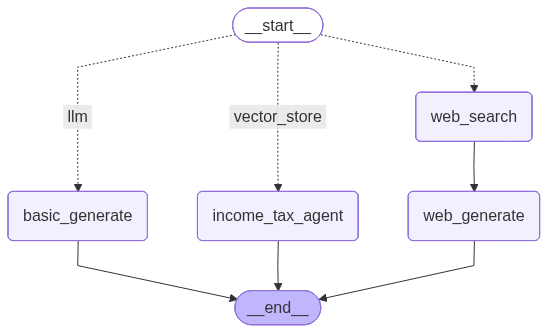

In [9]:
from IPython.display import Image, display

graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))  

# income_tax_agent, web_generate -> 좋은 LLM 모델을 쓰고
# income_tax_agent가 서브 그래프


#### initial state

In [ ]:
initial_state = {'query' : '대한민국의 수도는 어디인가요?'}
graph.invoke(initial_state)  # route response == llm

# 1. 답변이 오락가락 하고 있음
# 2. initial_state = {'query' : '대한민국의 수도는 어디인가요?'} -> llm 본인이 직접 답변을 함 (~대한민국의 수도는 서울입니다) -> end로 가는게 아닌 라우팅이니까 해결해줘야함


route response == llm


{'query': '대한민국의 수도는 어디인가요?', 'answer': '대한민국의 수도는 서울입니다.'}

In [ ]:
initial_state = {'query' : '연봉 5천만원인 거주자의 소득세는 얼마인가요?'}

graph.invoke(initial_state)  # route response == vector_store 로 잘 나옴 (토큰 문제로 중간에 멈춤 - 답변이 잘 안나오는데는 mini 모델을 써서 그럴수도 있다.)


route response == vector_store
context == [Document(id='88ace334-edae-4d17-b6ba-850b2c9b99a5', metadata={'source': './docs/income_tax.txt'}, page_content='② 제70조제1항, 제70조의2에 따른 제74조에 따라 차례로 할 것이 제70조제1항제2호에 따르며 서류를 제출하여야 한다는 경우에는 기준소득 중 거주자 본인이 된다(분산)과 제70조제2와 제74조에 따른 제료 및 제대법을 포함한다. 단, 차별제표청정인 그 업체를 남겨 제출한 경우로 그에 대하여 아니하다.<개정 2013. 1. 1.>\n  ③ 제80조에 따른 수익과 관련의 경우에는 기초공제 중 거주자 본인이 된다(분산)과 그에 관한 적지사항을 분명히 한다.\n[전문개정 2009. 12. 31.]\n[제목개정 2014. 1. 1.]\n제54조의2(공동사업에 대한 소득공제 등 특례) 제51조의3 또는 「조세특례제한법」에 따른 소득공제를 적용하거나 제59조의2에 따른 세액감면을 적용하는 경우 제54조제3항에 따라 공동사업자의 소득에 합산과세되는 특별세액거래의 지출․납입․투자 등의 금액이 있을 경우 주된 공동사업자의 소득에 합산과세되는 소득금액에 합산되어 주된 공동사업자의 합산과세세액은 공동사업소득액 또는 공동사업창출세액을 계산할 때 소득공제 또는 세액공제를 받을 수 있다. \n[개정 2014. 1. 1.]\n[전문개정 2009. 12. 31.]\n[제목개정 2014. 1. 1.]\n제2절 세액의 계산 <개정 2009. 12. 31.>\n제1관 세율 <개정 2009. 12. 31.>\n제55조(세율) 거주자의 종합소득에 대한 소득세는 해당 연도의 종합소득과세표준에 다음의 세율을 적용하여 계산한 금액(이하 "종합소득과세표준세액"이라 한다)을 그 세액으로 한다. <개정 2014. 1. 1., 2016. 12. 20., 2017. 12. 19., 2020. 12. 29., 2022. 12. 31.>\

KeyboardInterrupt: 

In [ ]:

initial_state = {'query' : '역삼역 맛집 추천해주세요'}
graph.invoke(initial_state) # route response == web_search


route response == web_search
web_search question == {'query': '역삼역 맛집 추천해주세요', 'follow_up_questions': None, 'answer': 'Recommended eateries near 역삼역 include 식신, 레스토랑 알렌, 대우부대찌개, and 서울집 for traditional Korean cuisine. For Italian, 지아니스나폴리 offers authentic Neapolitan pizza. For a diverse dining experience, try 고갯마루집 for spicy chicken soup.', 'images': ['https://imgssl.ezday.co.kr/cache/board/2012/10/16/b71f63e7eecaa7ed283a76ce022df2b1.jpg', 'https://img.siksinhot.com/place/1646975310440054.jpg', 'https://img.siksinhot.com/place/1554789466101144.jpg', 'https://postfiles.pstatic.net/MjAxOTA1MjVfNDcg/MDAxNTU4NzgwMzY2NzQ5.x5OBePAQenGvupnNp4eUvfRAEWhqA3uYsEuaO1M2eLIg.XjA2b8-OYD_QDDO7mEYNZr62S99AEx6H1WneC_x4njwg.JPEG.ww840825/IMG_0622.JPG?type=w966', 'https://img.siksinhot.com/seeon/1586138990283112.jpg'], 'results': [{'url': 'https://sam-repository.tistory.com/11', 'title': '역삼역 주변 맛집 리스트 - pangpang - 티스토리', 'content': "## 8. 서울집\n\n역삼역 맛집 8. 서울집\n\n \n\n키워드: #한식 #만두전골 #손만두 #도가니수육 #예약필수 #술  

{'query': '역삼역 맛집 추천해주세요',
 'context': {'query': '역삼역 맛집 추천해주세요',
  'follow_up_questions': None,
  'answer': 'Recommended eateries near 역삼역 include 식신, 레스토랑 알렌, 대우부대찌개, and 서울집 for traditional Korean cuisine. For Italian, 지아니스나폴리 offers authentic Neapolitan pizza. For a diverse dining experience, try 고갯마루집 for spicy chicken soup.',
  'images': ['https://imgssl.ezday.co.kr/cache/board/2012/10/16/b71f63e7eecaa7ed283a76ce022df2b1.jpg',
   'https://img.siksinhot.com/place/1646975310440054.jpg',
   'https://img.siksinhot.com/place/1554789466101144.jpg',
   'https://postfiles.pstatic.net/MjAxOTA1MjVfNDcg/MDAxNTU4NzgwMzY2NzQ5.x5OBePAQenGvupnNp4eUvfRAEWhqA3uYsEuaO1M2eLIg.XjA2b8-OYD_QDDO7mEYNZr62S99AEx6H1WneC_x4njwg.JPEG.ww840825/IMG_0622.JPG?type=w966',
   'https://img.siksinhot.com/seeon/1586138990283112.jpg'],
  'results': [{'url': 'https://sam-repository.tistory.com/11',
    'title': '역삼역 주변 맛집 리스트 - pangpang - 티스토리',
    'content': "## 8. 서울집\n\n역삼역 맛집 8. 서울집\n\n \n\n키워드: #한식 #만두전골 #손만두 #도